# Mini-dataset del Challenge 1
Crea un dataset pequeño a partir de los dos archivos originales:
- **2000 imágenes de entrenamiento** tomadas de `train.tgz` (15195 imágenes)
- **1000 imágenes de validación** tomadas de `val.tgz` (3796 imágenes)
- Muestreo **estratificado** en cada split (se mantiene el ~50% nevus / lesiones).

Estructura de salida:
```
mini_dataset/
├── train/<clase>/*.jpg   (2000, de train.tgz)
├── val/<clase>/*.jpg     (1000, de val.tgz)
├── train_labels.csv
└── val_labels.csv
```

## 1. Configuración

In [1]:
from pathlib import Path

ROOT = Path(r"C:\Users\Lenovo\PycharmProjects\Melanoma-Challenge-ML-UdG")

CFG = {
    "train": dict(tgz=None, extract=ROOT / "train", n=2000,
                  label_file=None, id_col=None, label_col=None),
    "val":   dict(tgz=None, extract=ROOT / "val",   n=1000,
                  label_file=None, id_col=None, label_col=None),
}
OUT_DIR = ROOT / "mini_dataset"
SEED = 42

## 2. Funciones: descomprimir, explorar y leer etiquetas

In [2]:
import tarfile
import pandas as pd

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def extract(tgz, dest):
    if dest.exists() and any(dest.iterdir()):
        print(f"[{dest.name}] ya descomprimido, se reutiliza {dest}")
        return
    assert tgz is not None, f"{dest} no existe o está vacío y no hay .tgz para descomprimir"
    dest.mkdir(parents=True, exist_ok=True)
    with tarfile.open(tgz, "r:gz") as tar:
        try:
            tar.extractall(dest, filter="data")
        except TypeError:               # Python < 3.12
            tar.extractall(dest)
    print(f"[{tgz.name}] descomprimido en {dest}")

def scan(dest):
    files = [p for p in dest.rglob("*") if p.is_file()]
    imgs = sorted(p for p in files if p.suffix.lower() in IMG_EXT)
    others = [p for p in files if p.suffix.lower() not in IMG_EXT]
    return imgs, others

def from_folders(imgs):
    classes = {p.parent.name for p in imgs}
    if 2 <= len(classes) <= 10:
        return pd.DataFrame({"path": imgs, "label": [p.parent.name for p in imgs]})

def from_csv(imgs, others, label_file=None, id_col=None, label_col=None):
    csvs = [label_file] if label_file else [p for p in others if p.suffix.lower() in {".csv", ".txt", ".tsv"}]
    by_stem = {p.stem: p for p in imgs}
    by_name = {p.name: p for p in imgs}
    for f in csvs:
        try:
            df = pd.read_csv(f, sep=None, engine="python")
        except Exception:
            continue
        if id_col is None:
            best, best_n = None, 0
            for c in df.columns:
                v = df[c].astype(str)
                n = v.isin(by_stem).sum() + v.isin(by_name).sum()
                if n > best_n: best, best_n = c, n
            if best is None or best_n < 0.5 * len(imgs):
                continue
            idc = best
        else:
            idc = id_col
        paths = df[idc].astype(str).map(lambda s: by_name.get(s, by_stem.get(Path(s).stem)))
        if label_col:
            labels = df[label_col].astype(str)
        else:
            rest = [c for c in df.columns if c != idc]
            num = [c for c in rest if pd.api.types.is_numeric_dtype(df[c]) and set(df[c].dropna().unique()) <= {0, 1, 0.0, 1.0}]
            if len(num) >= 2:                        # one-hot
                labels = df[num].idxmax(axis=1).astype(str)
            elif len(num) == 1 and len(rest) == 1:   # binaria 0/1
                labels = df[num[0]].map({0: "class_0", 1: "class_1"})
            else:
                cand = [c for c in rest if df[c].nunique() == 2]
                if not cand: continue
                labels = df[cand[0]].astype(str)
        print(f"   etiquetas leídas de {f} (ID='{idc}')")
        return pd.DataFrame({"path": paths, "label": labels}).dropna(subset=["path"])

def load_split(name, c):
    print(f"=== {name} ===")
    extract(c["tgz"], c["extract"])
    imgs, others = scan(c["extract"])
    print(f"   {len(imgs)} imágenes; otros archivos: {[p.name for p in others[:5]]}")
    meta = from_csv(imgs, others, c["label_file"], c["id_col"], c["label_col"])
    if meta is None:
        meta = from_folders(imgs)
    assert meta is not None, f"[{name}] No pude detectar las etiquetas: rellena label_file/id_col/label_col en CFG['{name}']."
    meta = meta.drop_duplicates("path").reset_index(drop=True)
    print(f"   {len(meta)} imágenes con etiqueta\n{meta['label'].value_counts().to_string()}\n")
    return meta

## 3. Cargar train y val

In [3]:
metas = {name: load_split(name, c) for name, c in CFG.items()}

=== train ===
[train] ya descomprimido, se reutiliza C:\Users\Lenovo\PycharmProjects\Melanoma-Challenge-ML-UdG\train
   15195 imágenes; otros archivos: []
   15195 imágenes con etiqueta
label
nevus     7725
others    7470

=== val ===
[val] ya descomprimido, se reutiliza C:\Users\Lenovo\PycharmProjects\Melanoma-Challenge-ML-UdG\val
   3796 imágenes; otros archivos: []
   3796 imágenes con etiqueta
label
nevus     1931
others    1865



## 4. Muestreo estratificado (2000 de train, 1000 de val)

In [4]:
from sklearn.model_selection import train_test_split

samples = {}
for name, c in CFG.items():
    meta = metas[name]
    assert len(meta) >= c["n"], f"[{name}] solo hay {len(meta)} imágenes, se piden {c['n']}"
    samples[name], _ = train_test_split(meta, train_size=c["n"], stratify=meta["label"], random_state=SEED)
    print(f"{name.upper()}: {len(samples[name])} imágenes")
    print(samples[name]["label"].value_counts().to_string(), "\n")

TRAIN: 2000 imágenes
label
nevus     1017
others     983 

VAL: 1000 imágenes
label
nevus     509
others    491 



## 5. Copiar imágenes y guardar CSVs

In [5]:
import shutil
from tqdm.auto import tqdm

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

for name, df in samples.items():
    rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=name):
        dst = OUT_DIR / name / str(r["label"]) / Path(r["path"]).name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(r["path"], dst)
        rows.append({"file": str(dst.relative_to(OUT_DIR)), "label": r["label"]})
    pd.DataFrame(rows).to_csv(OUT_DIR / f"{name}_labels.csv", index=False)

print("Listo ->", OUT_DIR.resolve())

train:   0%|          | 0/2000 [00:00<?, ?it/s]

val:   0%|          | 0/1000 [00:00<?, ?it/s]

Listo -> C:\Users\Lenovo\PycharmProjects\Melanoma-Challenge-ML-UdG\mini_dataset


## 6. Comprobación

train 2000 imágenes
val 1000 imágenes


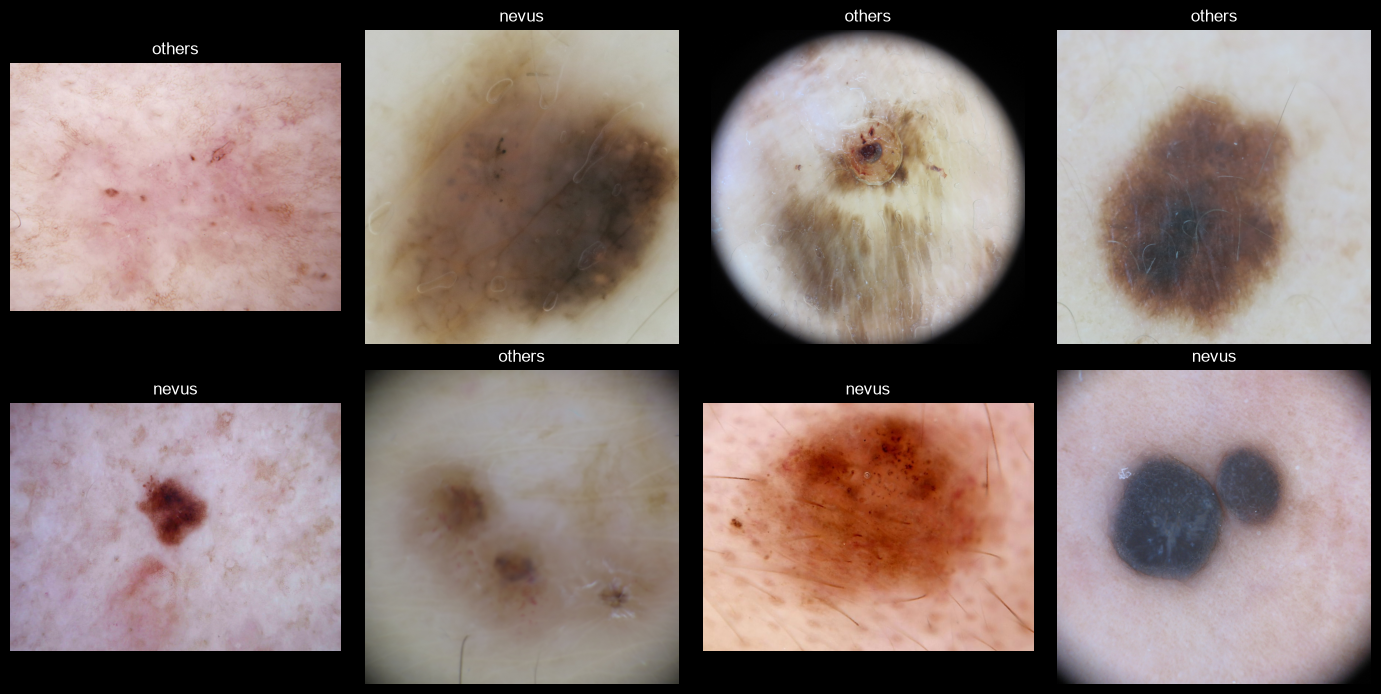

In [6]:
for split in ["train", "val"]:
    n = sum(1 for p in (OUT_DIR / split).rglob("*") if p.suffix.lower() in IMG_EXT)
    print(split, n, "imágenes")

import matplotlib.pyplot as plt
from PIL import Image

sample = samples["train"].sample(8, random_state=0)
fig, axs = plt.subplots(2, 4, figsize=(14, 7))
for ax, (_, r) in zip(axs.ravel(), sample.iterrows()):
    ax.imshow(Image.open(r["path"])); ax.set_title(r["label"]); ax.axis("off")
plt.tight_layout(); plt.show()

## (Opcional) Limpiar y comprimir
Borra las carpetas descomprimidas (ocupan ~7 GB) y/o genera un `.tgz` ligero.

In [7]:
# shutil.rmtree("train_raw"); shutil.rmtree("val_raw")
# shutil.make_archive("mini_dataset", "gztar", ".", str(OUT_DIR))